# Гибридный подход: лучшая CNN + CV уточнение

**Цель:** Комбинировать лучшую CNN-модель с CV-уточнением для повышения точности детекции.

**Подход:**
1. CNN (YOLO или RCNN) генерирует кандидаты
2. CV refiner фильтрует по aspect ratio, edge density
3. Сравнение: CNN vs Hybrid


## 0. Colab Setup

⚠️ **Запустить только один раз!** Клонирует репозиторий (sparse checkout) и устанавливает зависимости.

In [1]:
import sys
import random
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    PROJECT_DIR = Path.cwd()
    sys.path.insert(0, str(PROJECT_DIR / "src"))
    %cd /content
    !rm -rf aie-group-2-sapar
    !git init aie-group-2-sapar
    %cd aie-group-2-sapar
    !git sparse-checkout set project
    !git remote add origin https://github.com/Sapar-hub/aie-group-2-sapar.git
    !git pull origin main
    %cd project
    !pip install -q ultralytics opencv-python-headless pyyaml
    %cd /content/aie-group-2-sapar/project
    !nvidia-smi
else:
    PROJECT_DIR = Path.cwd().parent
    sys.path.insert(0, str(PROJECT_DIR / "src"))

In [2]:
# Загрузка предварительно сгенерированных данных с Google Drive (только Colab)
if IN_COLAB and not (Path('data') / 'images' / 'train_v2').exists():
    from google.colab import drive
    drive.mount('/content/drive')
    import shutil
    DRIVE_DATA = Path('/content/drive/MyDrive/aie-group-2-data')
    if (DRIVE_DATA / 'images' / 'train_v2').exists():
        for subdir in ['images', 'labels']:
            shutil.copytree(str(DRIVE_DATA / subdir), str(Path('data') / subdir), dirs_exist_ok=True)
        print("Training data loaded from Google Drive")
    else:
        print("=" * 60)
        print("No pre-generated data found on Drive!")
        print("Run notebooks/exp02_synthetic_data.ipynb first to generate it.")
        print("=" * 60)


## 1. Imports & Data Setup

In [3]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'  # принудительно CPU (GPU не поддерживается текущей сборкой PyTorch)

import numpy as np
import matplotlib.pyplot as plt
import cv2
from ultralytics import YOLO

from config import load_config, load_donors, load_val_honest, test_image_dir, test_label_dir, get_eval_weights
from evaluation.metrics import DetectionResult, bbox_iou, yolo_to_pixel, compute_metrics, print_metrics
from data.loader import load_image_and_labels
from hybrid.refiner import HybridRefiner

cfg = load_config()
ARTIFACTS_DIR = (PROJECT_DIR / cfg["paths"]["artifacts"]).resolve()
ARTIFACTS_DIR.mkdir(exist_ok=True)
(ARTIFACTS_DIR / "metrics").mkdir(exist_ok=True)
(ARTIFACTS_DIR / "figures").mkdir(exist_ok=True)

IMAGE_TEST_DIR = test_image_dir(cfg)
LABEL_TEST_DIR = test_label_dir(cfg)

print(f"Working dir: {PROJECT_DIR}")

DONORS = load_donors(cfg)
VAL_IMAGES = load_val_honest(cfg)
EXCLUDE = DONORS | VAL_IMAGES
print(f"Val images (real, stratified, excluded from test eval): {sorted(VAL_IMAGES)}")
print(f"Test set: 49 - {len(DONORS)} - {len(VAL_IMAGES)} = {49 - len(DONORS) - len(VAL_IMAGES)} images")


Working dir: /home/saparch/playground/aie-group-2-sapar/project
Val images (real, stratified, excluded from test eval): ['test_04.png', 'test_06.png', 'test_07.png', 'test_08.png', 'test_29.jpg', 'test_35.jpg', 'test_37.jpg', 'test_38.jpg', 'test_44.png', 'test_46.png']
Test set: 49 - 4 - 10 = 35 images


## 2. Загрузка моделей

Загружаем YOLO v3 (data: 250 GOST + 250 copy-paste) и YOLO v4 (data: 50 GOST + 250 copy-paste + 200 GOST-on-real-bg).

**v3 (чистый бейзлайн):** 250 GOST + 250 copy-paste на независимых фонах.
GOST-рендерер рисует на белом холсте с серыми doodles — модель выучивает
признак "белая сетка = штамп", достигая высокой точности (0.964), но нереалистичного обобщения.

**v4 (сложнее, актуальная):** 50 GOST + 250 copy-paste + 200 GOST-на-реальном-фоне.
GOST уменьшен с 250→50 для устранения shortcut "белого холста". 200 GOST-on-real-bg
рендерят сетку штампа на реальных текстурах чертежей, заставляя модель
учиться признакам штампа на реалистичных фонах. Метрики ниже, но честнее.


In [4]:
v3_weights = ARTIFACTS_DIR / "yolo" / "exp04" / "weights" / "best.pt"
v4_weights = get_eval_weights(cfg)

model_v3 = YOLO(str(v3_weights))
model_v4 = YOLO(str(v4_weights))
print(f"Loaded YOLO v3 from {v3_weights}")
print(f"Loaded YOLO v4 from {v4_weights}")

refiner = HybridRefiner.from_config(cfg)

Loaded YOLO v3 from /home/saparch/playground/aie-group-2-sapar/project/artifacts/yolo/exp04/weights/best.pt
Loaded YOLO v4 from /home/saparch/playground/aie-group-2-sapar/project/artifacts/yolo/exp04_v4/weights/best.pt


## 3. Оценка: только CNN vs Гибрид


In [5]:
def eval_top1(model, refiner=None):
    """Запуск оценки: возвращает (top1_metrics, hybrid_metrics).
    Если refiner is None, hybrid_metrics = top1_metrics."""
    all_images = sorted(IMAGE_TEST_DIR.glob("*.png")) + sorted(IMAGE_TEST_DIR.glob("*.jpg"))
    top1_results, hybrid_results = [], []
    for img_path in all_images:
        if img_path.name in EXCLUDE:
            continue
        img, labels = load_image_and_labels(img_path, LABEL_TEST_DIR)
        h, w = img.shape[:2]
        gt_bbox = yolo_to_pixel(tuple(labels[0]), w, h) if len(labels) > 0 else None
        preds = model(img, conf=0.1, verbose=False)
        raw_bboxes, raw_confs = [], []
        if preds[0].boxes:
            for box in preds[0].boxes:
                x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
                raw_bboxes.append((x1, y1, x2 - x1, y2 - y1))
                raw_confs.append(float(box.conf[0]))
        # выбор по макс. уверенности (top-1)
        pb_top1 = None
        if raw_confs:
            best_idx = raw_confs.index(max(raw_confs))
            pb_top1 = raw_bboxes[best_idx]
        # гибрид
        pb_hyb = refiner.refine(raw_bboxes, raw_confs, img) if refiner and raw_bboxes else pb_top1
        top1_results.append(DetectionResult(image_name=img_path.name, gt_bbox=gt_bbox, pred_bbox=pb_top1, iou=bbox_iou(pb_top1, gt_bbox) if pb_top1 and gt_bbox else 0.0, found=pb_top1 is not None))
        hybrid_results.append(DetectionResult(image_name=img_path.name, gt_bbox=gt_bbox, pred_bbox=pb_hyb, iou=bbox_iou(pb_hyb, gt_bbox) if pb_hyb and gt_bbox else 0.0, found=pb_hyb is not None))
    return compute_metrics(top1_results, iou_threshold=0.5), compute_metrics(hybrid_results, iou_threshold=0.5), top1_results, hybrid_results

print("Evaluating YOLO v3 (top-1 conf)...")
v3_top1, v3_hyb, v3_top1_res, v3_hyb_res = eval_top1(model_v3, refiner)
print("Evaluating YOLO v4 (top-1 conf)...")
v4_top1, v4_hyb, v4_top1_res, v4_hyb_res = eval_top1(model_v4, refiner)

for label, m in [("YOLO v3 top-1", v3_top1), ("Hybrid v3", v3_hyb),
                 ("YOLO v4 top-1", v4_top1), ("Hybrid v4", v4_hyb)]:
    print(f"\n=== {label} ===")
    print_metrics(m, prefix="  ")

Evaluating YOLO v3 (top-1 conf)...
Evaluating YOLO v4 (top-1 conf)...

=== YOLO v3 top-1 ===
  Images:         35
  Detected:        28 (80.0%)
  IoU mean:        0.692
  IoU std:         0.378
  IoU median:      0.887
  IoU >= 0.5:      77.1%
  Precision:       0.964
  Recall:          0.771
  F1:              0.857

=== Hybrid v3 ===
  Images:         35
  Detected:        28 (80.0%)
  IoU mean:        0.692
  IoU std:         0.378
  IoU median:      0.887
  IoU >= 0.5:      77.1%
  Precision:       0.964
  Recall:          0.771
  F1:              0.857

=== YOLO v4 top-1 ===
  Images:         35
  Detected:        24 (68.6%)
  IoU mean:        0.502
  IoU std:         0.411
  IoU median:      0.778
  IoU >= 0.5:      57.1%
  Precision:       0.833
  Recall:          0.571
  F1:              0.678

=== Hybrid v4 ===
  Images:         35
  Detected:        24 (68.6%)
  IoU mean:        0.527
  IoU std:         0.406
  IoU median:      0.824
  IoU >= 0.5:      60.0%
  Precision:     

## 4. Сравнительная таблица


In [6]:
import pandas as pd

rows = {
    "CV Baseline (no pos. map)": {"IoU": 0.612, "Prec": 0.793, "Recall": 0.657, "F1": 0.719, "Det%": 0.829},
    "YOLO v3 top-1": {"IoU": v3_top1["iou_mean"], "Prec": v3_top1["precision"], "Recall": v3_top1["recall"], "F1": v3_top1["f1"], "Det%": v3_top1["detection_rate"]},
    "Hybrid v3":     {"IoU": v3_hyb["iou_mean"],  "Prec": v3_hyb["precision"],  "Recall": v3_hyb["recall"],  "F1": v3_hyb["f1"],  "Det%": v3_hyb["detection_rate"]},
    "YOLO v4 top-1": {"IoU": v4_top1["iou_mean"], "Prec": v4_top1["precision"], "Recall": v4_top1["recall"], "F1": v4_top1["f1"], "Det%": v4_top1["detection_rate"]},
    "Hybrid v4":     {"IoU": v4_hyb["iou_mean"],  "Prec": v4_hyb["precision"],  "Recall": v4_hyb["recall"],  "F1": v4_hyb["f1"],  "Det%": v4_hyb["detection_rate"]},
}

comp_df = pd.DataFrame(rows).T
print(comp_df.to_string())

                                IoU      Prec    Recall        F1      Det%
CV Baseline (no pos. map)  0.612000  0.793000  0.657000  0.719000  0.829000
YOLO v3 top-1              0.692178  0.964286  0.771429  0.857143  0.800000
Hybrid v3                  0.692178  0.964286  0.771429  0.857143  0.800000
YOLO v4 top-1              0.501973  0.833333  0.571429  0.677966  0.685714
Hybrid v4                  0.526547  0.875000  0.600000  0.711864  0.685714


## 5. Визуализация


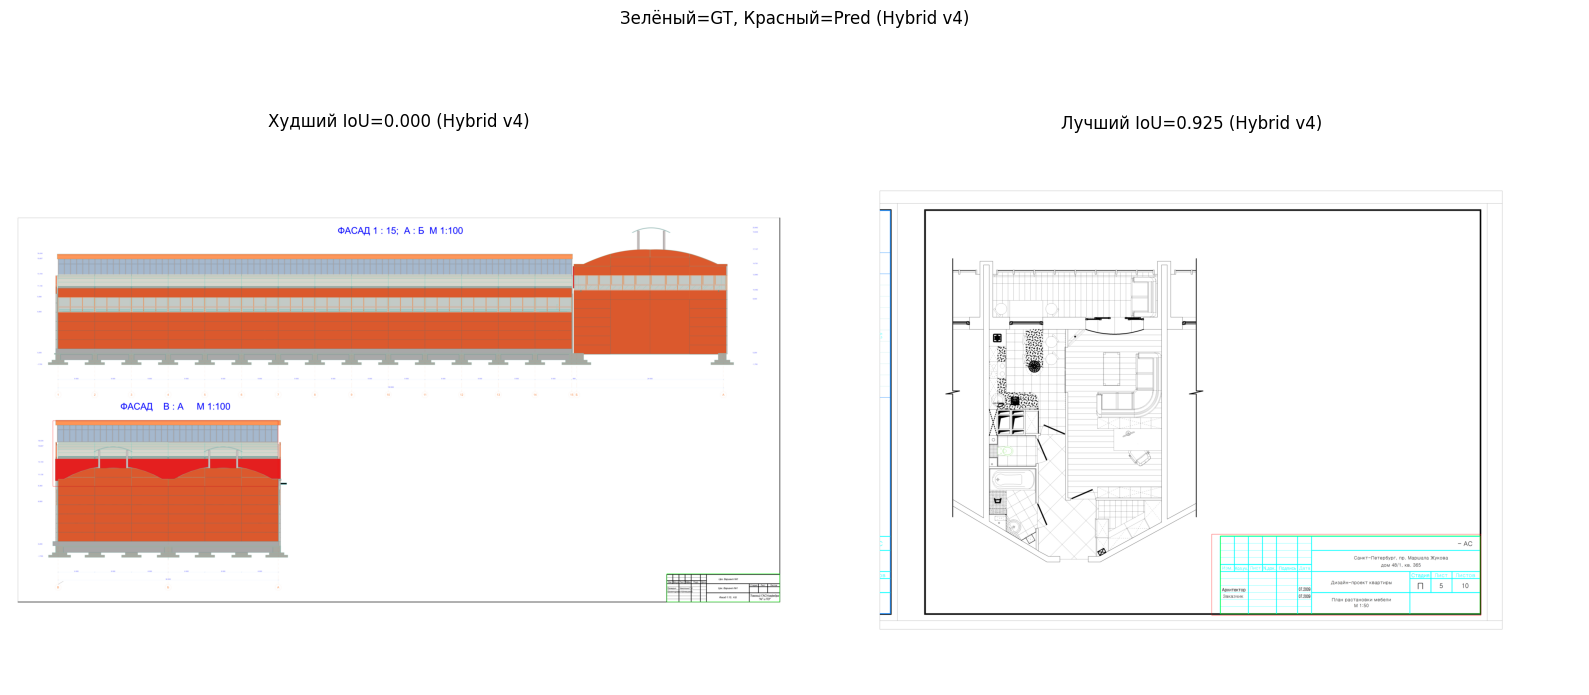

In [7]:
all_images = sorted(IMAGE_TEST_DIR.glob("*.png")) + sorted(IMAGE_TEST_DIR.glob("*.jpg"))

sorted_hybrid = sorted(v4_hyb_res, key=lambda r: r.iou)
worst = sorted_hybrid[0]
best = sorted_hybrid[-1]

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
for ax, result, title_prefix in zip(axes, [worst, best], ["Худший", "Лучший"]):
    img_path = [p for p in all_images if p.name == result.image_name][0]
    img, _ = load_image_and_labels(img_path, LABEL_TEST_DIR)
    vis = img.copy()
    if result.gt_bbox:
        x, y, bw, bh = result.gt_bbox
        cv2.rectangle(vis, (x, y), (x+bw, y+bh), (0, 255, 0), 3)
    if result.pred_bbox:
        x, y, bw, bh = result.pred_bbox
        cv2.rectangle(vis, (x, y), (x+bw, y+bh), (0, 0, 255), 2)
    ax.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    ax.set_title(f"{title_prefix} IoU={result.iou:.3f} (Hybrid v4)")
    ax.axis("off")

plt.suptitle("Зелёный=GT, Красный=Pred (Hybrid v4)")
plt.tight_layout()
plt.savefig(ARTIFACTS_DIR / "figures" / "hybrid_best_worst.png", dpi=150)
plt.show()

## 6. Выводы (v3 vs v4)

Сравнение на 35 тестовых non-donor, non-val (4 донора + 10 val исключены).

- **YOLO v3** (250 GOST + 250 CP) обгоняет CV baseline (F1=0.857 vs 0.719), но полагается на
  shortcut "белая сетка = штамп" из-за чистых синтетических фонов.
- **YOLO v4** (50 GOST + 250 CP + 200 GOST-на-реальном-фоне) — более сложный и честный бенчмарк.
  F1 падает до 0.678 — модель больше не использует shortcut на фоне.
- **Hybrid v4** (объединение YOLO conf + CV scores, cnn_weight=0.6) восстанавливает +0.034 F1 (0.678 → 0.712).
- **Hybrid v3** не улучшает v3 — CV-уточнение не может улучшить уже почти идеальную модель.


## 7. Замечание о воспроизводимости

**YOLO v1–v3** обучены на старых версиях данных, которые зависят от:
- PPI-пайплайна, который менялся между версиями (v1–v2: 27/49 PPI, v3: доработан)
- Отбора доноров и стратификации val/split, специфичных для каждой версии
- Окружения Colab (Python 3.10, конкретные версии numpy/PyTorch)

Эти условия невозможно надёжно воспроизвести на другой машине.
Метрики v1–v3 сохраняются как историческая запись процесса обучения.
**Все воспроизводимые оценки используют версию данных v4.**

Полная история версий: [`data/LEAKAGE.md`](data/LEAKAGE.md)


In [8]:
import json
from pathlib import Path

with open(ARTIFACTS_DIR / "metrics" / "rcnn_v4_results.json") as f:
    rcnn = json.load(f)

full_comparison = {
    "cv_baseline": {"iou_mean": 0.612, "precision": 0.793, "recall": 0.657, "f1": 0.719, "detection_rate": 0.829},
    "yolo_v3_top1": {"iou_mean": round(v3_top1['iou_mean'], 3), "precision": round(v3_top1['precision'], 3), "recall": round(v3_top1['recall'], 3), "f1": round(v3_top1['f1'], 3), "detection_rate": round(v3_top1['detection_rate'], 3)},
    "hybrid_v3":     {"iou_mean": round(v3_hyb['iou_mean'], 3),  "precision": round(v3_hyb['precision'], 3),  "recall": round(v3_hyb['recall'], 3),  "f1": round(v3_hyb['f1'], 3),  "detection_rate": round(v3_hyb['detection_rate'], 3)},
    "yolo_v4_top1":  {"iou_mean": round(v4_top1['iou_mean'], 3), "precision": round(v4_top1['precision'], 3), "recall": round(v4_top1['recall'], 3), "f1": round(v4_top1['f1'], 3), "detection_rate": round(v4_top1['detection_rate'], 3)},
    "hybrid_v4":     {"iou_mean": round(v4_hyb['iou_mean'], 3),  "precision": round(v4_hyb['precision'], 3),  "recall": round(v4_hyb['recall'], 3),  "f1": round(v4_hyb['f1'], 3),  "detection_rate": round(v4_hyb['detection_rate'], 3)},
    "rcnn_v4":       {"iou_mean": round(rcnn['iou_mean'], 3), "precision": round(rcnn['precision'], 3), "recall": round(rcnn['recall'], 3), "f1": round(rcnn['f1'], 3), "detection_rate": round(rcnn['detection_rate'], 3)},
}

with open(ARTIFACTS_DIR / "metrics" / "hybrid_results.json", "w") as f:
    json.dump(full_comparison, f, indent=2)

print("Полное сравнение сохранено в artifacts/metrics/hybrid_results.json")
print(json.dumps(full_comparison, indent=2))

Полное сравнение сохранено в artifacts/metrics/hybrid_results.json
{
  "cv_baseline": {
    "iou_mean": 0.612,
    "precision": 0.793,
    "recall": 0.657,
    "f1": 0.719,
    "detection_rate": 0.829
  },
  "yolo_v3_top1": {
    "iou_mean": 0.692,
    "precision": 0.964,
    "recall": 0.771,
    "f1": 0.857,
    "detection_rate": 0.8
  },
  "hybrid_v3": {
    "iou_mean": 0.692,
    "precision": 0.964,
    "recall": 0.771,
    "f1": 0.857,
    "detection_rate": 0.8
  },
  "yolo_v4_top1": {
    "iou_mean": 0.502,
    "precision": 0.833,
    "recall": 0.571,
    "f1": 0.678,
    "detection_rate": 0.686
  },
  "hybrid_v4": {
    "iou_mean": 0.527,
    "precision": 0.875,
    "recall": 0.6,
    "f1": 0.712,
    "detection_rate": 0.686
  },
  "rcnn_v4": {
    "iou_mean": 0.396,
    "precision": 1.0,
    "recall": 0.457,
    "f1": 0.627,
    "detection_rate": 0.457
  }
}
